# 05 — Autocorrelation

## The question

> I have a week of one-minute means: 10,080 numbers. How precisely do they pin down
> the average? How many independent observations do I actually have?

The naive answer takes 10,080 to be the sample size. That is the number that goes
into `sd / √n`, into a t-test and into a confidence interval, and here it is wrong in a
way that raises no error: every one-minute mean is nearly the same number as the
minute before it, so ten thousand of them are not ten thousand pieces of evidence.

The question is how many they are. This notebook answers it three ways, and the
interesting result is that the standard shortcut is the one that fails.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks._data import connect
from notebooks._style import apply_style, save, stamp

apply_style()
pd.set_option("display.width", 130)

conn = connect()
rollup = pd.read_sql("SELECT bucket, signal_id, mean FROM reading_1m", conn)
wide = rollup.pivot(index="bucket", columns="signal_id", values="mean")
minutes = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq="1min"))
print(f"{len(minutes):,} one-minute slots, {minutes.shape[1]} signals")

10,080 one-minute slots, 57 signals


```output
10,080 one-minute slots, 57 signals
```

Everything below uses the one-minute rollup on a regular grid of a week of minutes.
Slots where a signal wrote no reading are left empty and not filled: a filled gap is
an invented observation, and an invented observation is exactly what autocorrelation
rewards.

## How correlated is a minute with the one before it?

In [2]:
SIGNALS = {
    "PRIMARY:PRI-SCR-1:TORQUE": "scraper torque",
    "UTILITY:SITE:PLANT_POWER": "plant power",
    "AERATION:AHU-1:AIR_FLOW": "air flow",
    "INFLUENT:LIFT:FLOW": "lift-station flow",
    "EFFLUENT:FLOW:TSS": "effluent TSS",
    "AERATION:AHU-1:DO": "dissolved oxygen",
}
rows = []
for sig, label in SIGNALS.items():
    s = minutes[sig]
    rows.append(
        {
            "signal": label,
            "minutes with data": int(s.notna().sum()),
            "lag 1 min": s.autocorr(1),
            "lag 1 h": s.autocorr(60),
            "lag 1 day": s.autocorr(1440),
        }
    )
acf_table = pd.DataFrame(rows).set_index("signal")
print(acf_table.round(3).to_string())

                   minutes with data  lag 1 min  lag 1 h  lag 1 day
signal                                                             
scraper torque                 10080      0.988    0.495      0.555
plant power                     8874      0.997    0.491      0.993
air flow                        8474      0.997    0.502      0.992
lift-station flow               9125      0.980    0.436      0.809
effluent TSS                    7483      0.980    0.358      0.467
dissolved oxygen                1502      0.997   -0.176      0.988


```output
                   minutes with data  lag 1 min  lag 1 h  lag 1 day
signal                                                             
scraper torque                 10080      0.988    0.495      0.555
plant power                     8874      0.997    0.491      0.993
air flow                        8474      0.997    0.502      0.992
lift-station flow               9125      0.980    0.436      0.809
effluent TSS                    7483      0.980    0.358      0.467
dissolved oxygen                1502      0.997   -0.176      0.988
```

Read the first column of numbers. **Adjacent minutes correlate at 0.988 for the
scraper torque and at 0.997 for plant power**: knowing this minute tells you the next
one to two or three parts in a thousand. The last column is the plant's clock. Plant
power correlates **0.993** with itself a day earlier, and the dissolved-oxygen probe
**0.988**. Torque is the odd one out at **0.555**, and the reason turns up below: the
storm sits on one day of the seven.

the naive band is ±0.0195; the smallest ACF plotted is -0.369


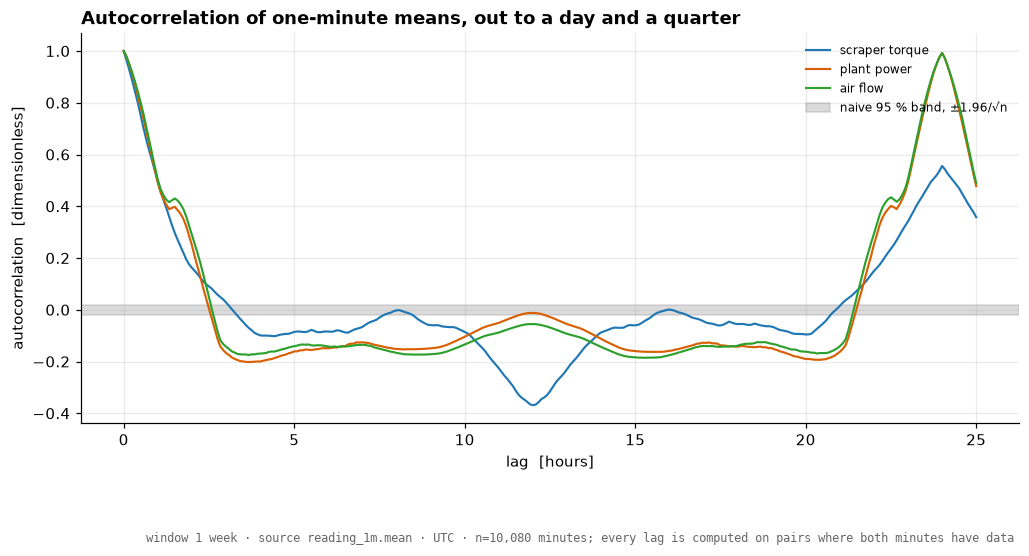

In [3]:
lags = np.arange(0, 1501, 5)
fig, ax = plt.subplots(figsize=(11, 4.6))
for sig, label in list(SIGNALS.items())[:3]:
    s = minutes[sig]
    ax.plot(lags / 60, [s.autocorr(int(k)) for k in lags], label=label)

n = int(minutes["PRIMARY:PRI-SCR-1:TORQUE"].notna().sum())
band = 1.96 / np.sqrt(n)
ax.axhspan(-band, band, color="#999999", alpha=0.35, label="naive 95 % band, ±1.96/√n")
ax.set_xlabel("lag  [hours]")
ax.set_ylabel("autocorrelation  [dimensionless]")
ax.set_title(
    "Autocorrelation of one-minute means, out to a day and a quarter",
    loc="left",
    fontweight="bold",
)
ax.legend(loc="upper right", fontsize=8)
stamp(
    ax,
    window="1 week",
    source="reading_1m.mean",
    extra=f"n={n:,} minutes;"
    f" every lag is computed on pairs where both minutes have data",
)
save(fig, "05_acf")
print(
    f"the naive band is ±{band:.4f}; the smallest ACF plotted is "
    f"{min(minutes[s].autocorr(int(k)) for s in list(SIGNALS)[:3] for k in lags):+.3f}"
)

```output
the naive band is ±0.0195; the smallest ACF plotted is -0.369
```

The grey band is the one every textbook draws: **0.0195** either side of zero, the
range in which an autocorrelation would count as insignificant for 10,080 independent
points. **Nothing is inside it.** The smallest value on the plot is **-0.369**, which
is the daily cycle swinging negative half a day away. A significance test on an
autocorrelation of this data answers a question nobody asked.

## The formula everyone reaches for

In [4]:
def n_effective(n, rho):
    """The AR(1) effective sample size: n (1 - rho) / (1 + rho)."""
    return n * (1 - rho) / (1 + rho)


rows = []
for sig, label in SIGNALS.items():
    s = minutes[sig]
    pairs = int((s.notna() & s.shift(1).notna()).sum())
    rho = s.autocorr(1)
    rows.append(
        {
            "signal": label,
            "pairs": pairs,
            "lag-1 rho": rho,
            "n_eff": n_effective(pairs, rho),
        }
    )
print(
    pd.DataFrame(rows)
    .set_index("signal")
    .round({"lag-1 rho": 4, "n_eff": 1})
    .to_string()
)

                   pairs  lag-1 rho  n_eff
signal                                    
scraper torque     10079     0.9877   62.6
plant power         8329     0.9973   11.4
air flow            7810     0.9973   10.7
lift-station flow   8746     0.9799   88.7
effluent TSS        7298     0.9795   75.5
dissolved oxygen     956     0.9966    1.6


```output
                   pairs  lag-1 rho  n_eff
signal                                    
scraper torque     10079     0.9877   62.6
plant power         8329     0.9973   11.4
air flow            7810     0.9973   10.7
lift-station flow   8746     0.9799   88.7
effluent TSS        7298     0.9795   75.5
dissolved oxygen     956     0.9966    1.6
```

The standard correction shrinks n by (1 − ρ)/(1 + ρ), using the lag-one correlation,
and it produces these: **62.6** effective observations for the torque's 10,079 pairs,
**11.4** for plant power, **10.7** for air flow and **1.6** for dissolved oxygen, out of
956 pairs. That last figure deserves a moment. The formula is saying that a week of
the probe's readings is worth about one and a half independent measurements.

In [5]:
print(f"{'rho':>9}  {'n_eff for n = 10,080':>22}")
for rho in (0.5, 0.9, 0.99, 0.999, 0.9999, 0.99999):
    print(f"{rho:9.5f}  {n_effective(10_080, rho):22.2f}")

      rho    n_eff for n = 10,080
  0.50000                 3360.00
  0.90000                  530.53
  0.99000                   50.65
  0.99900                    5.04
  0.99990                    0.50
  0.99999                    0.05


```output
      rho    n_eff for n = 10,080
  0.50000                 3360.00
  0.90000                  530.53
  0.99000                   50.65
  0.99900                    5.04
  0.99990                    0.50
  0.99999                    0.05
```

That is not a measurement of information. It is the formula running out of road.
As ρ approaches one, n_eff goes to zero in proportion to (1 − ρ): at 0.9999 it
returns **0.50** and at 0.99999 it returns **0.05** — fractions of an observation,
from a dataset that plainly contains at least one. A formula that can return less than
one has stopped describing the data and started describing its own assumption: that
all the dependence in the series is one parameter, ρ₁ raised to the lag. This series
has a daily cycle, and one parameter cannot say both "this minute resembles the last"
and "this minute resembles the same minute yesterday".

## What the data says instead

In [6]:
torque = minutes["PRIMARY:PRI-SCR-1:TORQUE"].to_numpy()
sd = torque.std(ddof=1)
print(f"n = {len(torque):,}   mean = {torque.mean():.3f} N.m   sd = {sd:.3f}")
print(f"naive SE of the mean = sd / sqrt(n) = {sd / np.sqrt(len(torque)):.4f}")


def block_bootstrap_se(x, block, replicates=2000, seed=20260929):
    """Standard error of the mean under a moving-block bootstrap."""
    rng = np.random.default_rng(seed)
    n = len(x)
    k = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=(replicates, k))
    cumulative = np.concatenate([[0.0], np.cumsum(x)])
    means = (cumulative[starts + block] - cumulative[starts]).sum(axis=1) / (k * block)
    return means.std(ddof=1)


rows = []
for block in (1, 15, 60, 360, 1440):
    se = block_bootstrap_se(torque, block)
    rows.append(
        {
            "block length [min]": block,
            "SE of the mean": se,
            "n_eff": (sd / se) ** 2,
            "95 % half-width": 1.96 * se,
        }
    )
result = pd.DataFrame(rows).set_index("block length [min]")
print(result.round({"SE of the mean": 4, "n_eff": 0, "95 % half-width": 3}).to_string())

n = 10,080   mean = 39.387 N.m   sd = 3.409
naive SE of the mean = sd / sqrt(n) = 0.0340
                    SE of the mean    n_eff  95 % half-width
block length [min]                                          
1                           0.0340  10034.0            0.067
15                          0.1293    695.0            0.253
60                          0.2430    197.0            0.476
360                         0.3466     97.0            0.679
1440                        0.1935    310.0            0.379


```output
n = 10,080   mean = 39.387 N.m   sd = 3.409
naive SE of the mean = sd / sqrt(n) = 0.0340
                    SE of the mean    n_eff  95 % half-width
block length [min]                                          
1                           0.0340  10034.0            0.067
15                          0.1293    695.0            0.253
60                          0.2430    197.0            0.476
360                         0.3466     97.0            0.679
1440                        0.1935    310.0            0.379
```

So ask the data. A moving-block bootstrap resamples *blocks* of consecutive minutes, so
whatever dependence lives inside a block is kept, and the standard error it produces
is the one the data supports. With a block of one minute it *is* the naive answer,
**0.0340**, by construction. Lengthen the block and the honest standard error climbs:
**0.1293** at fifteen minutes, **0.2430** at an hour, **0.3466** at six hours — an
effective sample of **97** independent observations, and not ten thousand.

Then it *falls*, to **0.1935** (an n_eff of **310**) at a full day. That is not noise.
A block a day long contains one complete cycle, so the daily rhythm averages out inside
every block and is no longer resampled as if it were random, and what remains is the
day-to-day variation. Which points at the real answer.

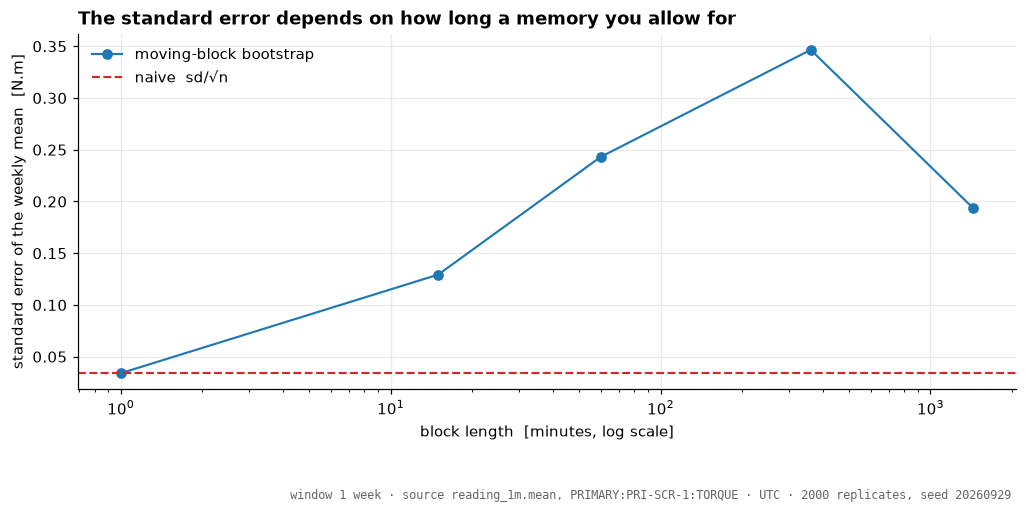

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(
    result.index, result["SE of the mean"], marker="o", label="moving-block bootstrap"
)
ax.axhline(
    sd / np.sqrt(len(torque)), color="#d62728", linestyle="--", label="naive  sd/√n"
)
ax.set_xscale("log")
ax.set_xlabel("block length  [minutes, log scale]")
ax.set_ylabel("standard error of the weekly mean  [N.m]")
ax.set_title(
    "The standard error depends on how long a memory you allow for",
    loc="left",
    fontweight="bold",
)
ax.legend()
stamp(
    ax,
    window="1 week",
    source="reading_1m.mean, PRIMARY:PRI-SCR-1:TORQUE",
    extra="2000 replicates, seed 20260929",
)
save(fig, "05_block_bootstrap")

The curve is the argument in one picture. The naive line is a floor nobody is
entitled to; the bootstrap sits about ten times above it at its worst; and the
*shape* — up, then down at a day — is the plant's clock, not a property of the
method.

In [8]:
daily = pd.Series(torque, index=minutes.index).resample("1D").mean()
print(daily.round(2).to_string())
print(f"\nmean of the {len(daily)} daily means = {daily.mean():.3f}")
print(
    f"SE from the {len(daily)} daily means "
    f" = {daily.std(ddof=1) / np.sqrt(len(daily)):.4f}"
)

2026-09-22 00:00:00+00:00    39.14
2026-09-23 00:00:00+00:00    39.20
2026-09-24 00:00:00+00:00    39.19
2026-09-25 00:00:00+00:00    39.19
2026-09-26 00:00:00+00:00    39.20
2026-09-27 00:00:00+00:00    40.59
2026-09-28 00:00:00+00:00    39.20
Freq: D

mean of the 7 daily means = 39.387
SE from the 7 daily means  = 0.2013


```output
2026-09-22 00:00:00+00:00    39.14
2026-09-23 00:00:00+00:00    39.20
2026-09-24 00:00:00+00:00    39.19
2026-09-25 00:00:00+00:00    39.19
2026-09-26 00:00:00+00:00    39.20
2026-09-27 00:00:00+00:00    40.59
2026-09-28 00:00:00+00:00    39.20
Freq: D

mean of the 7 daily means = 39.387
SE from the 7 daily means  = 0.2013
```

**The unit of independence in this dataset is the day.** Seven daily means say the same
thing with no machinery at all: their standard error is **0.2013**, within about four per cent
of the day-long block bootstrap. And look at what the table shows: six of the days sit
within 0.06 N.m of 39.2, and one — **40.59** — is 27 September, the storm. A week's
average of this signal is, in effect, seven observations, one of which is an event.

Three answers to one question, for every signal at once:

In [9]:
rows = []
for sig, label in SIGNALS.items():
    s = minutes[sig]
    v = s.dropna()
    pairs = int((s.notna() & s.shift(1).notna()).sum())
    day = s.resample("1D").mean().dropna()
    rows.append(
        {
            "signal": label,
            "naive SE": v.std() / np.sqrt(len(v)),
            "lag-1 formula SE": v.std() / np.sqrt(n_effective(pairs, s.autocorr(1))),
            "daily-means SE": day.std(ddof=1) / np.sqrt(len(day)),
            "days": len(day),
        }
    )
summary = pd.DataFrame(rows).set_index("signal")
summary["daily / naive"] = summary["daily-means SE"] / summary["naive SE"]
print(
    summary.round(
        {"naive SE": 4, "lag-1 formula SE": 4, "daily-means SE": 4, "daily / naive": 1}
    ).to_string()
)

                   naive SE  lag-1 formula SE  daily-means SE  days  daily / naive
signal                                                                            
scraper torque       0.0340            0.4310          0.2013     7            5.9
plant power          4.9518          138.3703          3.6474     7            0.7
air flow            71.8946         2022.1018         46.8154     7            0.7
lift-station flow    4.5088           45.7186         12.5706     7            2.8
effluent TSS         0.0454            0.4519          0.2279     7            5.0
dissolved oxygen     0.0092            0.2791          0.0084     7            0.9


```output
                   naive SE  lag-1 formula SE  daily-means SE  days  daily / naive
signal                                                                            
scraper torque       0.0340            0.4310          0.2013     7            5.9
plant power          4.9518          138.3703          3.6474     7            0.7
air flow            71.8946         2022.1018         46.8154     7            0.7
lift-station flow    4.5088           45.7186         12.5706     7            2.8
effluent TSS         0.0454            0.4519          0.2279     7            5.0
dissolved oxygen     0.0092            0.2791          0.0084     7            0.9
```

The last table is the one to keep. It gives each signal's standard error three ways.

**Torque and effluent TSS are known several times less precisely than the naive formula
claims**, by factors of **5.9** and **5.0**, and the storm day is in both. But plant
power and air flow come out at **0.7**: their daily means are *steadier* than the naive
formula thinks, because the naive formula counts the within-day cycle as noise, and the
cycle averages out exactly over whole days.

And the lag-one formula is wrong in *both* directions. For plant power it says the mean
is uncertain by **138.37** kW where the daily means say **3.65** — an error of nearly
forty times, from a signal whose lag-one correlation is 0.997.

## Takeaways

- **10,080 minute-means are not 10,080 observations.** Adjacent minutes correlate at
  **0.988** to **0.997**, and no autocorrelation on the plot falls inside the naive
  significance band of **0.0195**.
- **The lag-one formula fails, and fails where it matters most.** As ρ approaches one
  it returns fractions of an observation (**0.05** at ρ = 0.99999), and on this data
  it is wrong by a factor of **5.9** in one direction and nearly forty in the other.
- **The honest sample size depends on the memory you allow.** For the scraper torque
  it is **97** at a six-hour block and **310** at a day, and it changes shape at a day
  because the cycle averages out.
- **Use the unit the data respects.** Seven daily means give a standard error of
  **0.2013**, agreeing with the day-long block bootstrap to about four per cent.
- **A seasonal signal's mean is uncertain for a different reason than its
  variance is large.** Plant power's daily-means ratio is **0.7**: the cycle that
  makes its standard deviation large is not what makes its weekly mean uncertain.

## Exercises

1. **Find the memory.** Compute the block-bootstrap standard error for block lengths
   from one minute to two days on plant power (fill only the gaps of ten minutes or
   less, and say what that does). Where does it flatten, and what is that length?
2. **Take the storm out.** Repeat the daily-means comparison excluding 27 September.
   Which ratios in the summary table change, which do not, and what does that say about
   which signals are noisy and which merely have one event in them?
3. **Break the formula on purpose.** Simulate an AR(1) series with ρ = 0.99 and a
   sine wave of period 1,440 added to it. Compare the lag-one formula, the block
   bootstrap and the daily means, and show which one the sine wave hurts.
4. **How many days is enough?** Seven daily means gave a standard error of 0.2013. If
   the week were four days, or fourteen, what would the interval be, and what would
   you have to assume about the days you did not see?

---

**Next:** [06 — Detrending and differencing](06-detrending-and-differencing.ipynb) ·
**Back to the series** [README](README.md) ·
**Previous:** [04 — Resampling buys you nothing](04-resampling-buys-you-nothing.ipynb)